# NeuralProphet 时序预测——零售需求（含协变量）

使用 NeuralProphet 预测门店下一季度（13周）的周销售额，以 **Open**、**Promo**、**SchoolHoliday**、**StateHoliday** 作为已知未来协变量，并与不含协变量的基线对比。

数据：AutoGluon retail_sales（Rossmann 门店销售，周频，门店 ID = "1"）

预测步长：13 周

In [43]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ''
os.environ['TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD'] = '1'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from neuralprophet import NeuralProphet, set_log_level
set_log_level('ERROR')

plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False

TIMESERIES_ID     = '1'
PREDICTION_LENGTH = 13
SHOW_HISTORY      = 104

sales_context_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/train.parquet',
    engine='fastparquet'
)
sales_context_df['timestamp'] = pd.to_datetime(sales_context_df['timestamp'])

sales_test_df = pd.read_parquet(
    'https://autogluon.s3.amazonaws.com/datasets/timeseries/retail_sales/test.parquet',
    engine='fastparquet'
)
sales_test_df['timestamp'] = pd.to_datetime(sales_test_df['timestamp'])

print('训练数据:', sales_context_df.shape, '| 列:', list(sales_context_df.columns))
print(f'时间范围: {sales_context_df["timestamp"].min().date()} ~ {sales_context_df["timestamp"].max().date()}')
print('预测期:', sales_test_df['timestamp'].min().date(), '~', sales_test_df['timestamp'].max().date())
sales_context_df.head(3)

Epoch 270: 100%|██████████| 270/270 [12:55<00:00,  0.35it/s]    
训练数据: (133800, 8) | 列: ['id', 'timestamp', 'Sales', 'Open', 'Promo', 'SchoolHoliday', 'StateHoliday', 'Customers']
时间范围: 2013-01-13 ~ 2015-04-26
预测期: 2015-05-03 ~ 2015-07-26


,id,timestamp,Sales,Open,Promo,SchoolHoliday,StateHoliday,Customers
0,1,2013-01-13,32952.0,0.857143,0.714286,5.0,0.0,3918.0
1,1,2013-01-20,25978.0,0.857143,0.000000,0.0,0.0,3417.0
2,1,2013-01-27,33071.0,0.857143,0.714286,0.0,0.0,3862.0


In [44]:
FUTURE_COVS = ['Open', 'Promo', 'SchoolHoliday', 'StateHoliday']

df_context = (
    sales_context_df[sales_context_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds', 'Sales': 'y'})
    [['ds', 'y'] + FUTURE_COVS]
    .reset_index(drop=True)
)

df_future_cov = (
    sales_test_df[sales_test_df['id'] == TIMESERIES_ID]
    .rename(columns={'timestamp': 'ds'})
    [['ds'] + FUTURE_COVS]
    .reset_index(drop=True)
)

print(f'历史上下文: {len(df_context)} 行  ({df_context["ds"].min().date()} ~ {df_context["ds"].max().date()})')
print(f'未来协变量: {len(df_future_cov)} 行  ({df_future_cov["ds"].iloc[0].date()} ~ {df_future_cov["ds"].iloc[-1].date()})')
df_context.tail(3)

历史上下文: 120 行  (2013-01-13 ~ 2015-04-26)
未来协变量: 13 行  (2015-05-03 ~ 2015-07-26)


,ds,y,Open,Promo,SchoolHoliday,StateHoliday
117,2015-04-12,19546.0,0.714286,0.000000,5.0,1.0
118,2015-04-19,27563.0,0.857143,0.714286,0.0,0.0
119,2015-04-26,20670.0,0.857143,0.000000,0.0,0.0


In [45]:
# NeuralProphet（含协变量）
# n_forecasts=1, n_lags=0：与 Prophet 对齐的分解式模式
m_with_cov = NeuralProphet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    quantiles=[0.1, 0.9],
    n_forecasts=1,
    n_lags=0,
    trainer_config={'accelerator': 'cpu'},
)
for col in FUTURE_COVS:
    m_with_cov.add_future_regressor(col)

print('开始训练…')
m_with_cov.fit(df_context, freq='W')
print('NeuralProphet 模型训练完成（含协变量）')

开始训练…
Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 208/208 [00:01<00:00, 114.10it/s]


Training: |          | 0/? [00:14<?, ?it/s, v_num=2, train_loss=0.0276, reg_loss=0.000, MAE=1.57e+3, RMSE=2.05e+3, Loss=0.0273, RegLoss=0.000]
NeuralProphet 模型训练完成（含协变量）


In [46]:
future_w_cov = m_with_cov.make_future_dataframe(
    df=df_context, periods=PREDICTION_LENGTH, regressors_df=df_future_cov)
forecast_w_cov = m_with_cov.predict(future_w_cov)
future_pred_w  = forecast_w_cov.tail(PREDICTION_LENGTH)

print('预测完成')
future_pred_w[['ds', 'yhat1', 'yhat1 10.0%', 'yhat1 90.0%']]

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 245.21it/s]
预测完成


,ds,yhat1,yhat1 10.0%,yhat1 90.0%
0,2015-05-03,26416.167969,24249.914062,27849.220703
1,2015-05-10,27036.941406,24621.910156,28674.484375
2,2015-05-17,18983.677734,17739.066406,19160.187500
3,2015-05-24,26898.343750,24649.759766,28078.792969
4,2015-05-31,19440.679688,18366.230469,19511.556641
5,2015-06-07,26409.476562,24568.269531,27177.759766
6,2015-06-14,21159.804688,19618.015625,22123.343750
7,2015-06-21,27647.218750,25442.503906,29122.472656
8,2015-06-28,20767.210938,19544.070312,21446.257812
9,2015-07-05,27171.359375,25635.164062,27952.765625


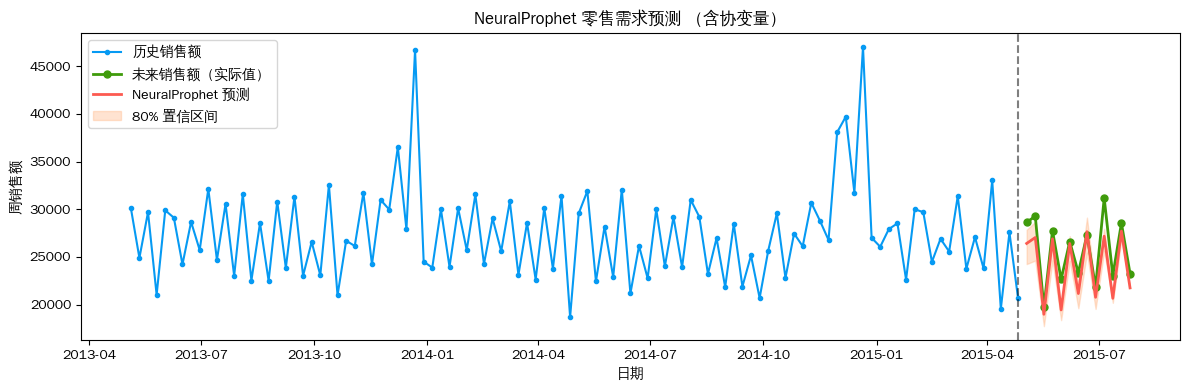

In [47]:
def plot_np_retail(df_context, future_forecast, sales_test_df,
                   timeseries_id, title_suffix=''):
    df_hist = df_context.tail(SHOW_HISTORY)
    df_gt   = (sales_test_df[sales_test_df['id'] == timeseries_id]
               .rename(columns={'timestamp': 'ds'}))

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df_hist['ds'], df_hist['y'],
            label='历史销售额', color='xkcd:azure', marker='o', markersize=3)
    ax.plot(df_gt['ds'], df_gt['Sales'],
            label='未来销售额（实际值）', color='xkcd:grass green', marker='o', markersize=5, linewidth=2)
    ax.plot(future_forecast['ds'], future_forecast['yhat1'],
            label='NeuralProphet 预测', color='xkcd:coral', linewidth=2)
    if 'yhat1 10.0%' in future_forecast.columns:
        ax.fill_between(future_forecast['ds'],
                        future_forecast['yhat1 10.0%'], future_forecast['yhat1 90.0%'],
                        alpha=0.35, label='80% 置信区间', color='xkcd:peach')
    ax.axvline(x=df_context['ds'].max(), color='black', linestyle='--', alpha=0.5)
    ax.set_title(f'NeuralProphet 零售需求预测 {title_suffix}')
    ax.set_xlabel('日期')
    ax.set_ylabel('周销售额')
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

plot_np_retail(df_context, future_pred_w, sales_test_df,
               TIMESERIES_ID, title_suffix='（含协变量）')

开始训练（不含协变量）…
Training: |          | 0/? [00:00<?, ?it/s]

Finding best initial lr: 100%|██████████| 208/208 [00:01<00:00, 141.74it/s]


Training: |          | 0/? [00:14<?, ?it/s, v_num=3, train_loss=0.101, reg_loss=0.000, MAE=3.54e+3, RMSE=4.17e+3, Loss=0.0978, RegLoss=0.000]
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 298.65it/s]


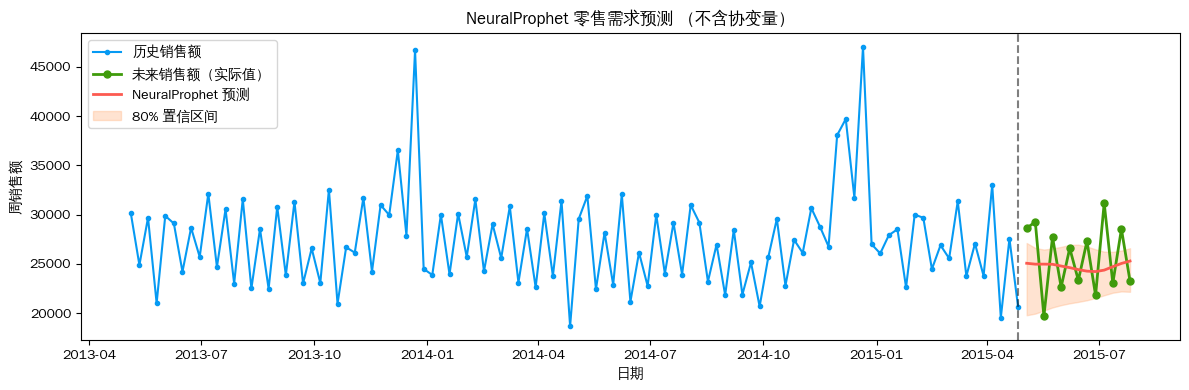

In [48]:
m_no_cov = NeuralProphet(
    yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
    seasonality_mode='multiplicative', quantiles=[0.1, 0.9],
    n_forecasts=1, n_lags=0, trainer_config={'accelerator': 'cpu'},
)
print('开始训练（不含协变量）…')
m_no_cov.fit(df_context[['ds', 'y']], freq='W')

future_no_cov    = m_no_cov.make_future_dataframe(df=df_context[['ds', 'y']], periods=PREDICTION_LENGTH)
forecast_no_cov  = m_no_cov.predict(future_no_cov)
future_pred_nc   = forecast_no_cov.tail(PREDICTION_LENGTH)

plot_np_retail(df_context, future_pred_nc, sales_test_df,
               TIMESERIES_ID, title_suffix='（不含协变量）')

In [49]:
gt = (sales_test_df[sales_test_df['id'] == TIMESERIES_ID]
      .sort_values('timestamp')['Sales'].values)

def calc_metrics(y_true, y_pred, label):
    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label}  MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.2f}%')

print('─' * 55)
calc_metrics(gt, future_pred_w['yhat1'].values,  'NeuralProphet 含协变量:  ')
calc_metrics(gt, future_pred_nc['yhat1'].values, 'NeuralProphet 不含协变量:')
print('─' * 55)

───────────────────────────────────────────────────────
NeuralProphet 含协变量:    MAE=1669.7  RMSE=2002.1  MAPE=6.53%
NeuralProphet 不含协变量:  MAE=3119.6  RMSE=3471.8  MAPE=12.13%
───────────────────────────────────────────────────────
